In [6]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

files = sorted(glob.glob('ST/raw/*.csv'))
print(f'{len(files)} files found:')
for f in files:
    print(' ', f)

10 files found:
  ST/raw/H20.33.002_1217501042.csv
  ST/raw/H20.33.004_1218552392.csv
  ST/raw/H20.33.035_1194111812.csv
  ST/raw/H20.33.044_1172983302.csv
  ST/raw/H21.33.001_1217500590.csv
  ST/raw/H21.33.011_1217500810.csv
  ST/raw/H21.33.014_1217501462.csv
  ST/raw/H21.33.015_1162693727.csv
  ST/raw/H21.33.016_1217499825.csv
  ST/raw/H21.33.031_1296510469.csv


Loaded ST/raw/H20.33.002_1217501042.csv: 9715953 transcripts, 160 genes
0 SECRET case transcripts
664500 SECRET ctrl transcripts


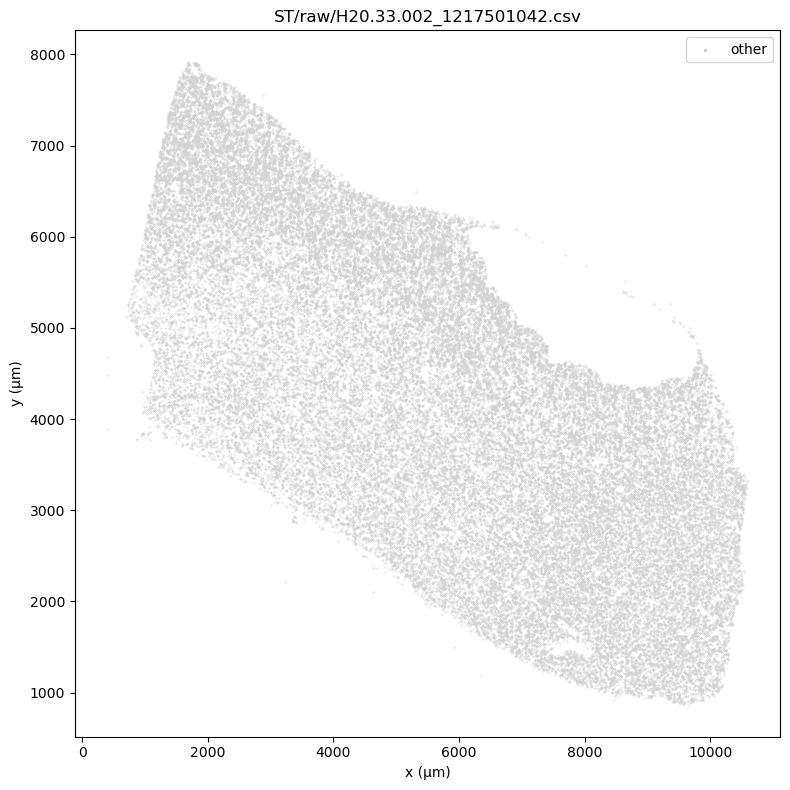

Loaded ST/raw/H20.33.004_1218552392.csv: 10334342 transcripts, 160 genes
1897500 SECRET case transcripts
0 SECRET ctrl transcripts


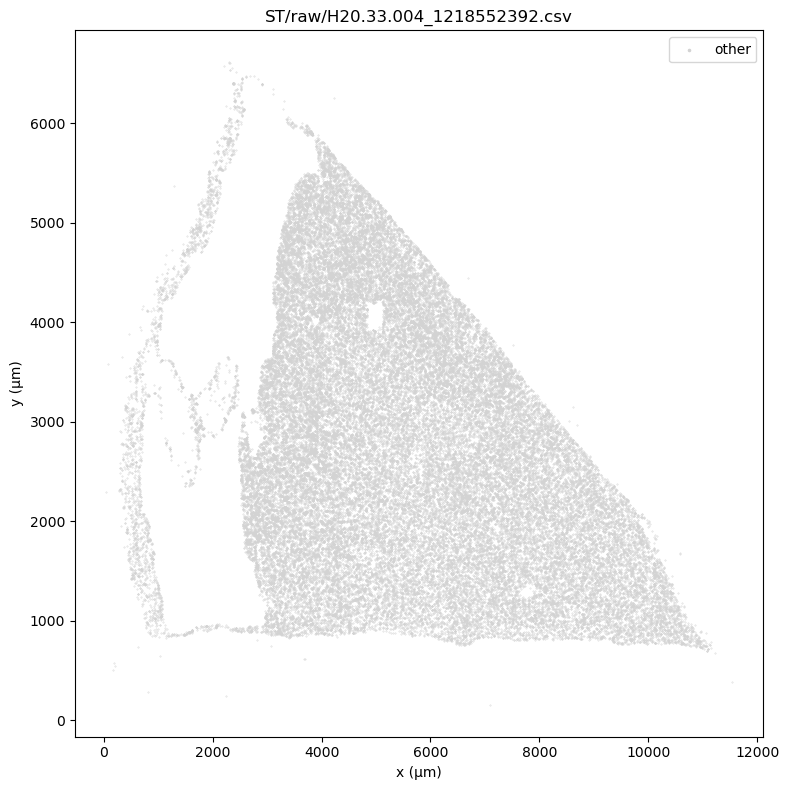

KeyboardInterrupt: 

In [ ]:
secret_case_genes = [f'SECRET{i}' for i in range(1,21)]
secret_ctrl_genes = [f'SECRET{i}' for i in range(21,41)]
for path in files:
    df = pd.read_csv(path)
    print(f'Loaded {path}: {len(df)} transcripts, {df.gene.nunique()} genes')
    
    secret_case = df[df.gene.isin(secret_case_genes)]
    secret_ctrl = df[df.gene.isin(secret_ctrl_genes)]
    other  = df[~df.gene.str.contains('SECRET')]
    print(f'{len(secret_case)} SECRET case transcripts')
    print(f'{len(secret_ctrl)} SECRET ctrl transcripts')

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(other.iloc[::100].global_x,  other.iloc[::100].global_y,  s=0.1, c='lightgray', rasterized=True, label='other')
    ax.scatter(secret_case.global_x, secret_case.global_y, s=2,   c='red',       rasterized=True, label='SECRET')
    ax.scatter(secret_ctrl.global_x, secret_ctrl.global_y, s=2,   c='blue',       rasterized=True, label='SECRET')
    ax.set_xlabel('x (µm)')
    ax.set_ylabel('y (µm)')
    ax.set_title(path)
    ax.legend(markerscale=5)
    plt.tight_layout()
    plt.show()
    

In [ ]:
path = files[1]
df = pd.read_csv(path)
print(df.gene.value_counts().tail(5))